In [1]:
import time
import torch
import matplotlib.pyplot as plt
from torch import nn, Tensor
from sklearn.datasets import make_moons
from sklearn.datasets import make_swiss_roll

# flow_matching
from flow_matching.path import AffineProbPath, CondOTProbPath
from flow_matching.path.scheduler import (
    CondOTScheduler, PolynomialConvexScheduler, LinearVPScheduler, CosineScheduler
)
from flow_matching.solver import ODESolver 
from flow_matching.utils import ModelWrapper 

# visualization
import matplotlib.pyplot as plt
from matplotlib import cm


In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

Using device: mps


In [3]:
class FlowModel(nn.Module):
    def __init__(self, dim=2, h=256):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim))
    
    def forward(self, x: Tensor, t: Tensor) -> Tensor:
        t = t.expand(*x.shape[:-1], 1) if t.dim() == 0 else t.view(-1, 1).expand(*x.shape[:-1], -1)
        return self.net(torch.cat((t, x), dim=-1))

velocity_model = FlowModel()
velocity_model.to(device)


FlowModel(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=256, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=256, out_features=2, bias=True)
  )
)

#### Dataset

Data shape: (5000, 2)


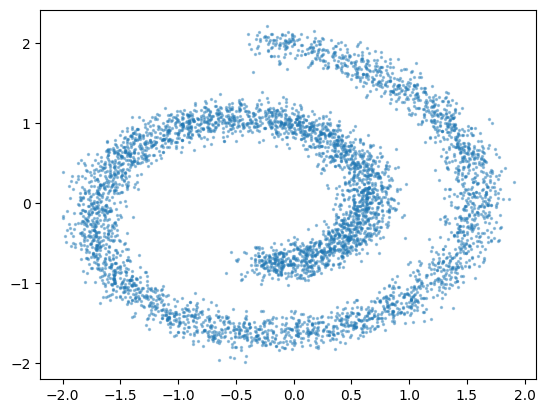

In [4]:
def get_data_batch(batch_size: int, noise: float = 0.8) -> Tensor:
    return Tensor(make_swiss_roll(batch_size, noise=noise)[0][:, [0, 2]])

X = get_data_batch(5000)
X = (X - X.mean(dim=0)) / X.std(dim=0)
X = X.numpy()
plt.scatter(X[:, 0], X[:, 1], s=2, alpha=0.4)

print("Data shape:", X.shape)

#### Training

In [ ]:
N_STEPS = 10_000
BATCH_SIZE = 8192   # 256   # 256
NOISE = 0.2
LEARNING_RATE = 1e-3
PRINT_EVERY = 2000 

# -- Define paths
# affine path with alpha_t = t, sigma_t = 1 - t
path = AffineProbPath(scheduler=CondOTScheduler())

# -- Initialize model
model = FlowModel()
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.MSELoss()
losses = []

# -- Training loop
start_time = time.time()
for i in range(N_STEPS):
    # Randomize time t ~ Uniform(0, 1)
    t = torch.rand(BATCH_SIZE).to(device)

    # Sample x1 and x0 (x0 is gaussian)
    x1 = get_data_batch(BATCH_SIZE, noise=NOISE).to(device)
    x0 = torch.randn_like(x1).to(device)

    # # Randomize time t ~ Uniform(0, 1)
    # t = torch.rand(len(x1), 1).to(device)

    # Sample path
    sample = path.sample(t=t, x_0=x0, x_1=x1)

    # Compute loss and optimize
    loss = torch.pow(model(t=t, x=sample.x_t) - sample.x_1, 2).mean()
    # loss = torch.pow(model(t=t, x=sample.x_t) - sample.dx_t, 2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    # log loss
    if (i+1) % PRINT_EVERY == 0:
        elapsed = time.time() - start_time
        print('| iter {:6d} | {:5.2f} ms/step | loss {:8.3f} ' 
              .format(i+1, elapsed*1000/PRINT_EVERY, loss.item())) 
        start_time = time.time()


| iter   2000 | 13.42 ms/step | loss    6.813 
| iter   4000 | 12.43 ms/step | loss    6.803 
| iter   6000 | 12.79 ms/step | loss    6.899 
| iter   8000 | 12.57 ms/step | loss    6.946 
| iter  10000 | 11.85 ms/step | loss    6.766 
| iter  12000 | 12.29 ms/step | loss    7.041 
| iter  14000 | 12.19 ms/step | loss    6.809 
| iter  16000 | 12.73 ms/step | loss    6.483 
| iter  18000 | 12.93 ms/step | loss    6.984 
| iter  20000 | 12.73 ms/step | loss    6.911 


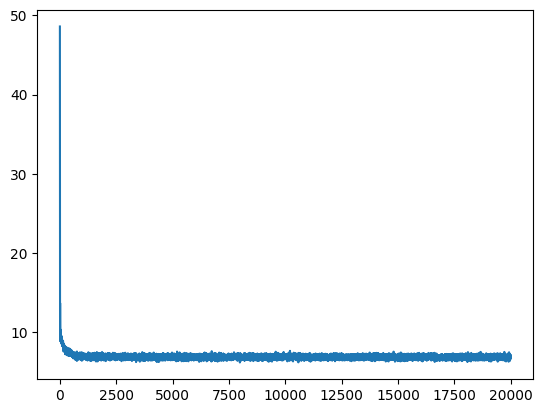

In [6]:
plt.plot(losses)

#### Sampling x1

In [7]:
# Convert from denoiser to velocity prediction
class VelocityModel(ModelWrapper):
    def __init__(self, denoiser: nn.Module, path: AffineProbPath):
        super().__init__(denoiser)
        self.path = path

    def forward(self, t: Tensor, x: Tensor, **extras) -> Tensor:
        x_1_predictions = super().forward(t=t, x=x, **extras)
        return self.path.target_to_velocity(x_1=x_1_predictions, x_t=x, t=t)

In [8]:
num_steps = 10
batch_size = 50_000
T = torch.linspace(0, 1, num_steps) 

velocity_model = VelocityModel(denoiser=model, path=path)
solver = ODESolver(velocity_model=velocity_model)

x_init = torch.randn((batch_size, 2), dtype=torch.float32, device=device)
x_1 = solver.sample(
    time_grid=T,
    x_init=x_init,
    method='midpoint',
    step_size=1.0 / num_steps,
    return_intermediates=True,
)

print("Sampled x_1 shape:", x_1.shape)

Sampled x_1 shape: torch.Size([10, 50000, 2])


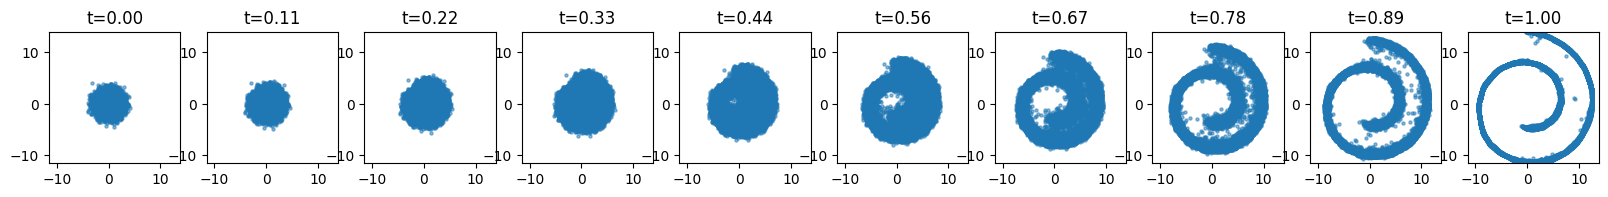

In [9]:
x_1 = x_1.cpu().numpy()

x_min, x_max = x_1.min(), x_1.max()
_, axs = plt.subplots(1, num_steps, figsize=(20, 3.2))

for i in range(num_steps):
    axs[i].scatter(x_1[i, :, 0], x_1[i, :, 1], s=5, alpha=0.5)
    axs[i].set_title(f"t={T[i].item():.2f}")
    axs[i].set_xlim(x_min, x_max)
    axs[i].set_ylim(x_min, x_max)
    axs[i].set_aspect('equal')

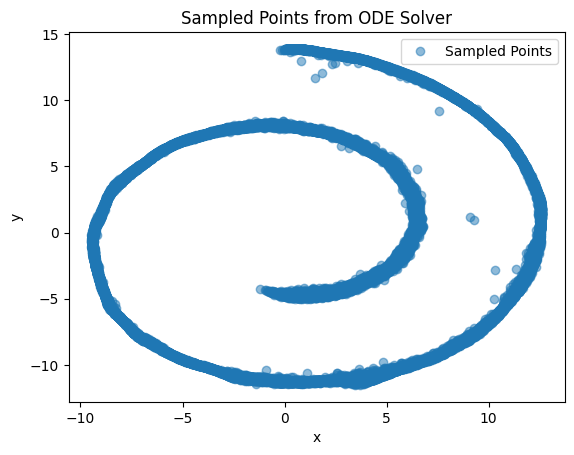

x_1 shape: (10, 50000, 2)


In [10]:
plt.plot(x_1[-1, :, 0], x_1[-1, :, 1], 'o', alpha=0.5, label='Sampled Points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Sampled Points from ODE Solver')
plt.legend()
plt.show()

print("x_1 shape:", x_1.shape)

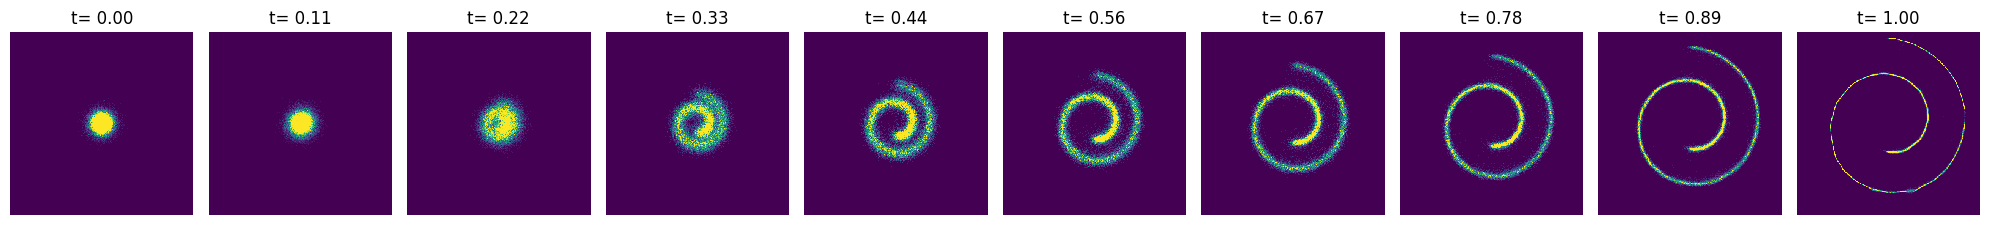

In [11]:
T = T.cpu()

fig, axs = plt.subplots(1, 10,figsize=(20,20))

for i in range(10):
    H= axs[i].hist2d(x_1[i,:,0], x_1[i,:,1], 300, range=((-15, 15), (-15, 15)))
    
    cmin = 0.0
    cmax = torch.quantile(torch.from_numpy(H[0]), 0.99).item()
    
    norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)
    
    _ = axs[i].hist2d(x_1[i,:,0], x_1[i,:,1], 300, range=((-15, 15), (-15, 15)), norm=norm)
    
    axs[i].set_aspect('equal')
    axs[i].axis('off')
    axs[i].set_title('t= %.2f' % (T[i]))
    
plt.tight_layout()
plt.show()

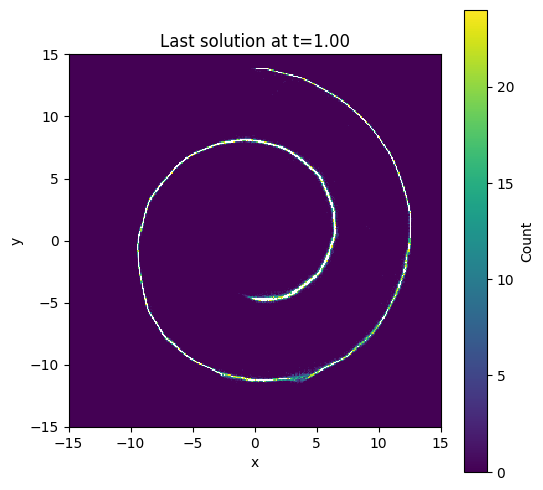

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(x_1[-1, :, 0], x_1[-1, :, 1], s=1, alpha=0.3)
plt.gca().set_aspect('equal')
plt.title(f'Last solution at t={float(T[-1]):.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.clf()

norm = cm.colors.Normalize(vmin=cmin, vmax=cmax)
plt.hist2d(
    x_1[-1, :, 0],
    x_1[-1, :, 1],
    bins=300,
    range=((-15, 15), (-15, 15)),
    cmap='viridis',
    cmin=cmin,
    cmax=cmax,
    norm=norm
)

plt.gca().set_aspect('equal')
plt.title(f'Last solution at t={float(T[-1]):.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='Count')
plt.show()

### Scheduler Change

In [13]:
from flow_matching.path.scheduler import ScheduleTransformedModel, LinearVPScheduler

In [14]:
# Change the scheduler to LinearVPScheduler and see how the samples evolve
transformed_model = ScheduleTransformedModel(
    velocity_model=model, 
    original_scheduler=CondOTScheduler(),
    new_scheduler=CosineScheduler(),
)

# Sanoke the transformed model with conditional OT schedule
solver = ODESolver(velocity_model=transformed_model)
x_0 = torch.randn((batch_size, 2), dtype=torch.float32, device=device)

num_steps = 10
T = torch.linspace(0, 1, num_steps)
x_1 = solver.sample(
    time_grid=T,
    x_init=x_0,
    method='midpoint',
    step_size=1.0 / num_steps,
    return_intermediates=True,
)

x_1 = x_1.cpu().numpy()
print("Sampled x_1 shape:", x_1.shape)

Sampled x_1 shape: (10, 50000, 2)


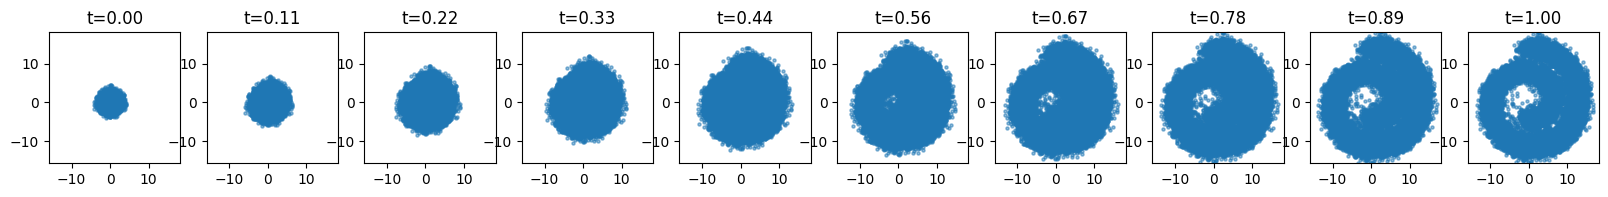

In [15]:
x_min, x_max = x_1.min(), x_1.max()
_, axs = plt.subplots(1, num_steps, figsize=(20, 3.2))

for i in range(num_steps):
    axs[i].scatter(x_1[i, :, 0], x_1[i, :, 1], s=5, alpha=0.5)
    axs[i].set_title(f"t={T[i].item():.2f}")
    axs[i].set_xlim(x_min, x_max)
    axs[i].set_ylim(x_min, x_max)
    axs[i].set_aspect('equal')

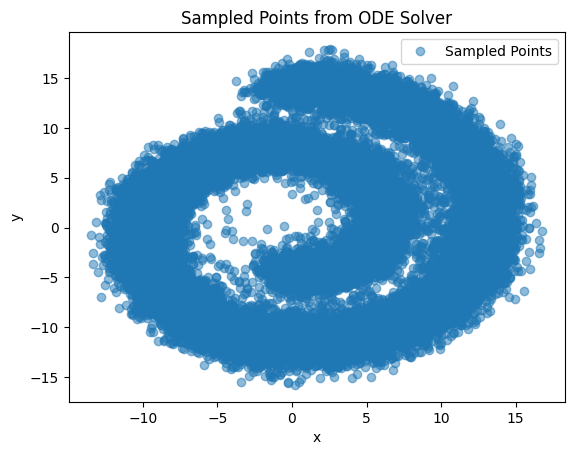

x_1 shape: (10, 50000, 2)


In [16]:
plt.plot(x_1[-1, :, 0], x_1[-1, :, 1], 'o', alpha=0.5, label='Sampled Points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Sampled Points from ODE Solver')
plt.legend()
plt.show()

print("x_1 shape:", x_1.shape)

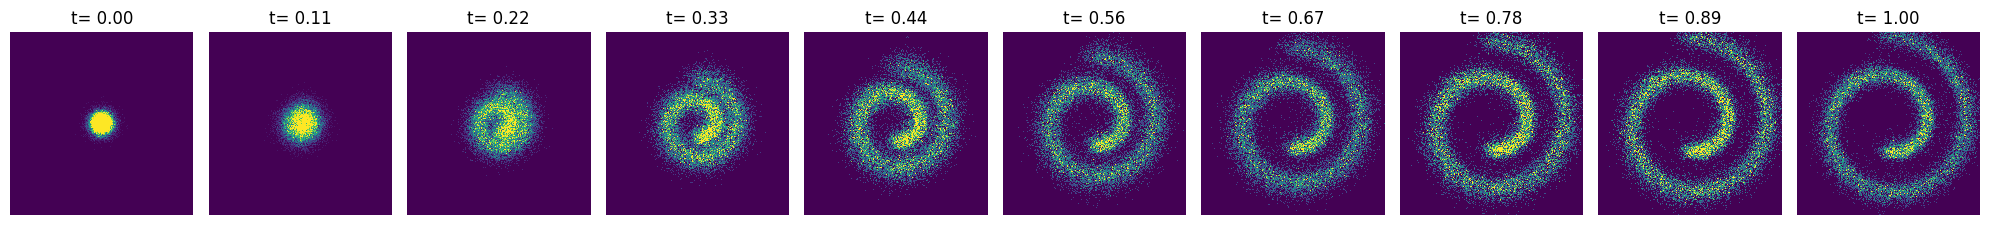

In [17]:
fig, axs = plt.subplots(1, 10,figsize=(20,20))

for i in range(10):
    H= axs[i].hist2d(x_1[i,:,0], x_1[i,:,1], 300, range=((-15, 15), (-15, 15)))
    
    cmin = 0.0
    cmax = torch.quantile(torch.from_numpy(H[0]), 0.99).item()
    
    norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)
    
    _ = axs[i].hist2d(x_1[i,:,0], x_1[i,:,1], 300, range=((-15, 15), (-15, 15)), norm=norm)
    
    axs[i].set_aspect('equal')
    axs[i].axis('off')
    axs[i].set_title('t= %.2f' % (T[i]))
    
plt.tight_layout()
plt.show()

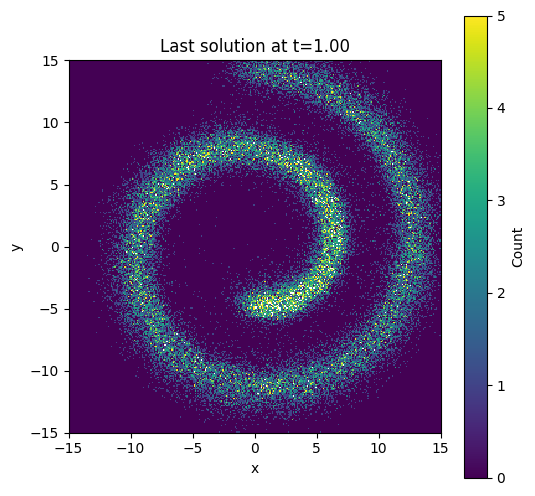

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(x_1[-1, :, 0], x_1[-1, :, 1], s=1, alpha=0.3)
plt.gca().set_aspect('equal')
plt.title(f'Last solution at t={float(T[-1]):.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.clf()

norm = cm.colors.Normalize(vmin=cmin, vmax=cmax)
plt.hist2d(
    x_1[-1, :, 0],
    x_1[-1, :, 1],
    bins=300,
    range=((-15, 15), (-15, 15)),
    cmap='viridis',
    cmin=cmin,
    cmax=cmax,
    norm=norm
)

plt.gca().set_aspect('equal')
plt.title(f'Last solution at t={float(T[-1]):.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='Count')
plt.show()